# Calidad de datos, aumentación y generalización visual

En la actividad anterior se construyó una CNN capaz de clasificar seis tipos de escenas naturales. El modelo alcanzó 86.20% de accuracy en test, pero también mostró diferencias importantes entre clases y señales iniciales de sobreajuste.

En esta actividad no se busca construir una CNN diferente. El objetivo es investigar si es posible mejorar su capacidad de generalización modificando únicamente los datos que observa durante entrenamiento mediante data augmentation.

## Preparación del entorno

In [1]:
import copy
import random
import pandas as pd
from pathlib import Path
from PIL import Image
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 99

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)
print("Semilla:", SEED)

PyTorch: 2.14.0
Dispositivo: mps
Semilla: 99


## Recuperar el escenario de referencia

El baseline representa el punto de comparación: la misma CNN se entrenó con redimensionado, conversión a tensor y normalización, pero sin perturbaciones aleatorias. Sus métricas permiten separar una mejora real de una variación causada únicamente por el entrenamiento.

El error de referencia más relevante es la confusión de `glacier` con `mountain`, por lo que además de la exactitud global se seguirá el comportamiento de estas dos clases

In [2]:
baseline_results = {
    "experiment": "Baseline",
    "augmentation": "None",
    "best_epoch": 12,
    "best_val_loss": 0.3841,
    "test_accuracy": 0.8620,
    "forest_f1": 0.9585,
    "glacier_f1": 0.8093,
    "main_confusion": "glacier → mountain",
    "main_confusion_count": 83
}

baseline_results

{'experiment': 'Baseline',
 'augmentation': 'None',
 'best_epoch': 12,
 'best_val_loss': 0.3841,
 'test_accuracy': 0.862,
 'forest_f1': 0.9585,
 'glacier_f1': 0.8093,
 'main_confusion': 'glacier → mountain',
 'main_confusion_count': 83}

In [3]:
MEAN = [0.43040627241134644, 0.4574933350086212, 0.4535215198993683]
STD  = [0.2693118751049042, 0.2678605616092682, 0.2985861897468567]

## Hipótesis sobre glacier → mountain

¿Por qué podría una CNN confundir glacier con mountain?

La matriz de confusión demuestra que existen 83 casos glacier → mountain, pero no demuestra por qué ocurrieron.
La inspección visual permitió observar elementos compartidos:

- nieve
- roca
- relieve
- cielo
- estructuras montañosas
- diferencias de iluminación
- distintas proporciones de glaciar y montaña dentro de la imagen.

A partir de ello se formulan tres hipótesis.

- Hipótesis 1: Apariencia luminosa  
El modelo podría depender demasiado de determinadas condiciones de brillo o contraste para distinguir las clases.

- Hipótesis 2: Color  
El modelo podría depender de determinadas características cromáticas de nieve, hielo, cielo, vegetación o roca.

- Hipótesis 3: Composición  
El modelo podría depender demasiado de dónde aparecen el glaciar y la montaña o de cuánto espacio ocupan dentro de la imagen.

Estas son hipótesis no conclusiones sobre el funcionamiento interno de la CNN

## Cargar el conjunto de datos

Se utiliza Intel Image Classification, organizado en seis categorías de escenas: `buildings`, `forest`, `glacier`, `mountain`, `sea` y `street`. El directorio de test se mantiene separado y no participa en el ajuste ni en la selección del mejor modelo

La validación se reconstruye a partir de `seg_train` mediante una partición estratificada. De este modo, cada escenario ve exactamente las mismas imágenes de entrenamiento y validación; solo cambia la transformación aplicada al subconjunto de entrenamiento

In [4]:
# Directorios de origen: entrenamiento y prueba independiente.
TRAIN_DIR = "data/intel-image-classification/seg_train"
TEST_DIR = "data/intel-image-classification/seg_test"

# Hiperparámetros y configuración del experimento.
IMAGE_SIZE = 150
BATCH_SIZE = 128
VAL_FRACTION = 0.15
EPOCHS = 20
LR = 1e-3
LEARNING_RATE = 0.001

In [5]:
base_dataset = datasets.ImageFolder(TRAIN_DIR)
class_names = base_dataset.classes
targets = np.array(base_dataset.targets)

print("Clases:", class_names)
print("Imágenes:", len(base_dataset))

Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Imágenes: 14034


### Reconstruir train y validation

La partición es estratificada y reproducible. La comprobación de intersección debe devolver cero: si hubiera imágenes compartidas entre train y validation, la estimación de generalización estaría contaminada

In [6]:
all_indices = np.arange(
    len(base_dataset)
)

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=targets
)

train_indices = train_indices.tolist()
val_indices = val_indices.tolist()

In [7]:
print(
    "Train:",
    len(train_indices)
)

print(
    "Validation:",
    len(val_indices)
)

print(
    "Intersección:",
    len(set(train_indices) & set(val_indices))
)

Train: 11227
Validation: 2807
Intersección: 0


In [8]:
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

### Reconstruir la CNN

Se reutiliza `SceneCNN`, una red convolucional compacta con tres bloques de convolución, activación ReLU y max-pooling, seguida de `AdaptiveAvgPool2d` y dos capas densas

In [9]:
class SceneCNN(nn.Module):

    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((3, 3))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3,128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

### Funciones de entrenamiento

`train_one_epoch` calcula la pérdida y la accuracy sobre los lotes de entrenamiento. También registra por separado el tiempo de espera del `DataLoader` y el tiempo de cómputo

In [10]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    data_time = 0.0
    compute_time = 0.0

    end = time.perf_counter()

    for images, labels in loader:

        # Tiempo esperando al DataLoader
        data_time += (time.perf_counter() - end)

        images = images.to(device)
        labels = labels.to(device)

        compute_start = time.perf_counter()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        compute_time += (time.perf_counter() - compute_start)
        running_loss += (loss.item() * images.size(0))
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        end = time.perf_counter()

    epoch_loss = (running_loss / total)

    epoch_accuracy = (correct / total)

    return (
        epoch_loss,
        epoch_accuracy,
        data_time,
        compute_time
    )

### Validación

La validación se ejecuta en modo evaluación y sin gradientes. Su pérdida se usa para guardar el estado de la mejor época, evitando seleccionar necesariamente el último modelo cuando aparece sobreajuste

In [11]:
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs,labels)
            running_loss += (loss.item() * images.size(0))
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = (running_loss / total)
    epoch_accuracy = (correct / total)

    return (
        epoch_loss,
        epoch_accuracy
    )

### Predicción

La función de predicción recoge las etiquetas reales y las clases con mayor probabilidad para calcular después métricas globales, métricas por clase y matrices de confusión sobre el mismo conjunto de evaluación

In [12]:
def predict_dataset(
    model,
    loader,
    device
):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())

    return (
        np.array(y_true),
        np.array(y_pred)
    )

## Diseñar transformaciones para poner a prueba las hipótesis

Cada transformación se elige para intervenir sobre una hipótesis concreta y se aplica únicamente durante el entrenamiento. La validación y el test conservan una transformación determinista, de forma que la comparación mida robustez y no cambios en el protocolo de evaluación

### Brillo y contraste

`ColorJitter` modifica brillo y contraste sin alterar la geometría de la escena. Esta prueba evalúa si el modelo puede dejar de asociar una clase con una iluminación específica y conservar la decisión cuando cambian las condiciones visuales

In [13]:
brightness_contrast_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.50, contrast=0.50),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

### Saturación

La variación de saturación altera la intensidad cromática, pero conserva la estructura espacial. Es una prueba directa de la hipótesis de que el color puede estar funcionando como una señal demasiado fuerte para separar `glacier` y `mountain`

In [14]:
saturation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(saturation=0.50),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

### Encuadre

`RandomResizedCrop` cambia ligeramente el encuadre y la escala, obligando a la red a utilizar patrones menos dependientes de la posición exacta del contenido

In [15]:
crop_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

## Verificar que las transformaciones preservan las etiquetas

In [16]:
preview_transforms = {
    "Brightness + Contrast": transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ColorJitter(brightness=0.50, contrast=0.50)
    ]),

    "Saturation": transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ColorJitter(saturation=0.50)
    ]),

    "RandomResizedCrop": transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1))
    ])
}

In [17]:
glacier_idx = class_names.index("glacier")
mountain_idx = class_names.index("mountain")

glacier_path = next(
    path
    for path, label in base_dataset.samples
    if label == glacier_idx
)

mountain_path = next(
    path
    for path, label in base_dataset.samples
    if label == mountain_idx
)

In [18]:
def show_transformations(
    image_path,
    preview_transforms,
    repetitions=3
):
    original = Image.open(image_path).convert("RGB")

    rows = len(preview_transforms)
    cols = repetitions + 1

    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))

    for row, (name, transform) in enumerate(preview_transforms.items()):
        axes[row, 0].imshow(original)
        axes[row, 0].set_title(f"{name}\nOriginal")
        axes[row, 0].axis("off")

        for col in range(1, cols):
            transformed = transform(original)
            axes[row, col].imshow(transformed)
            axes[row, col].set_title(f"Variación {col}")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

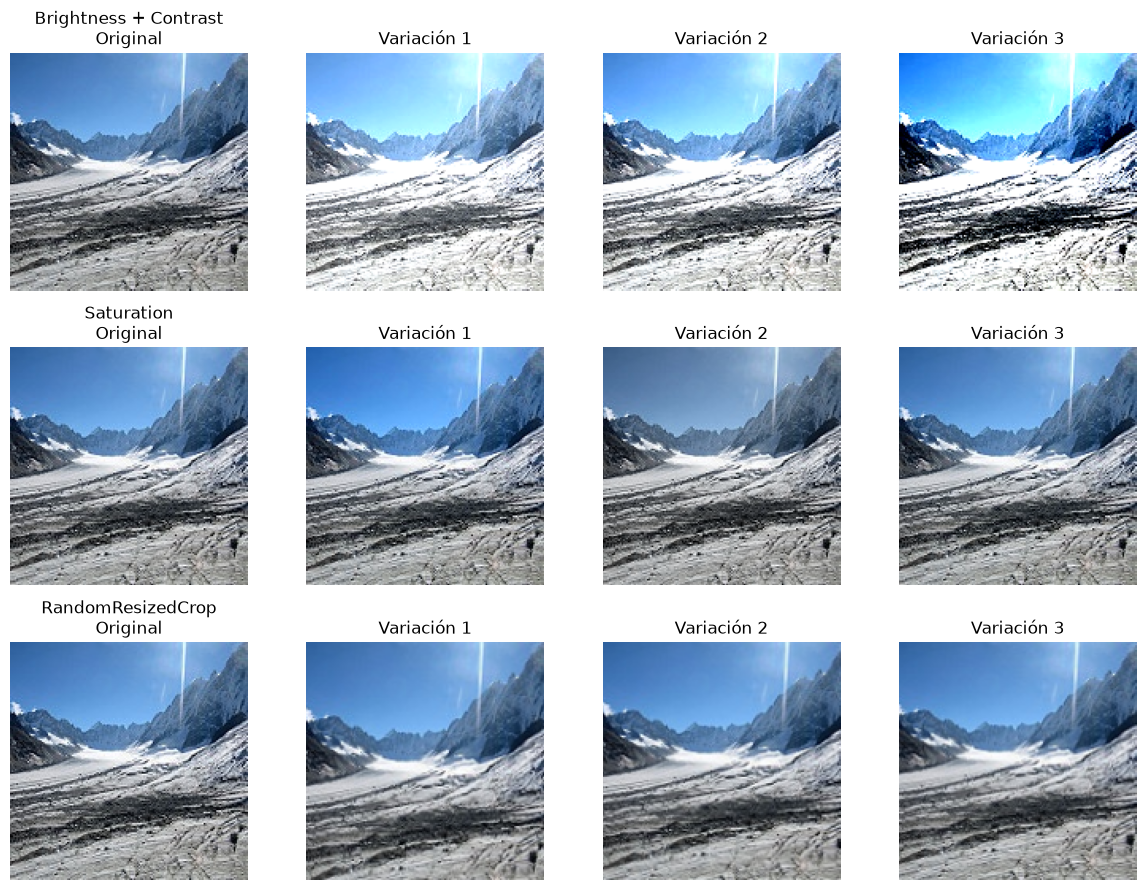

In [19]:
show_transformations(
    glacier_path,
    preview_transforms
)

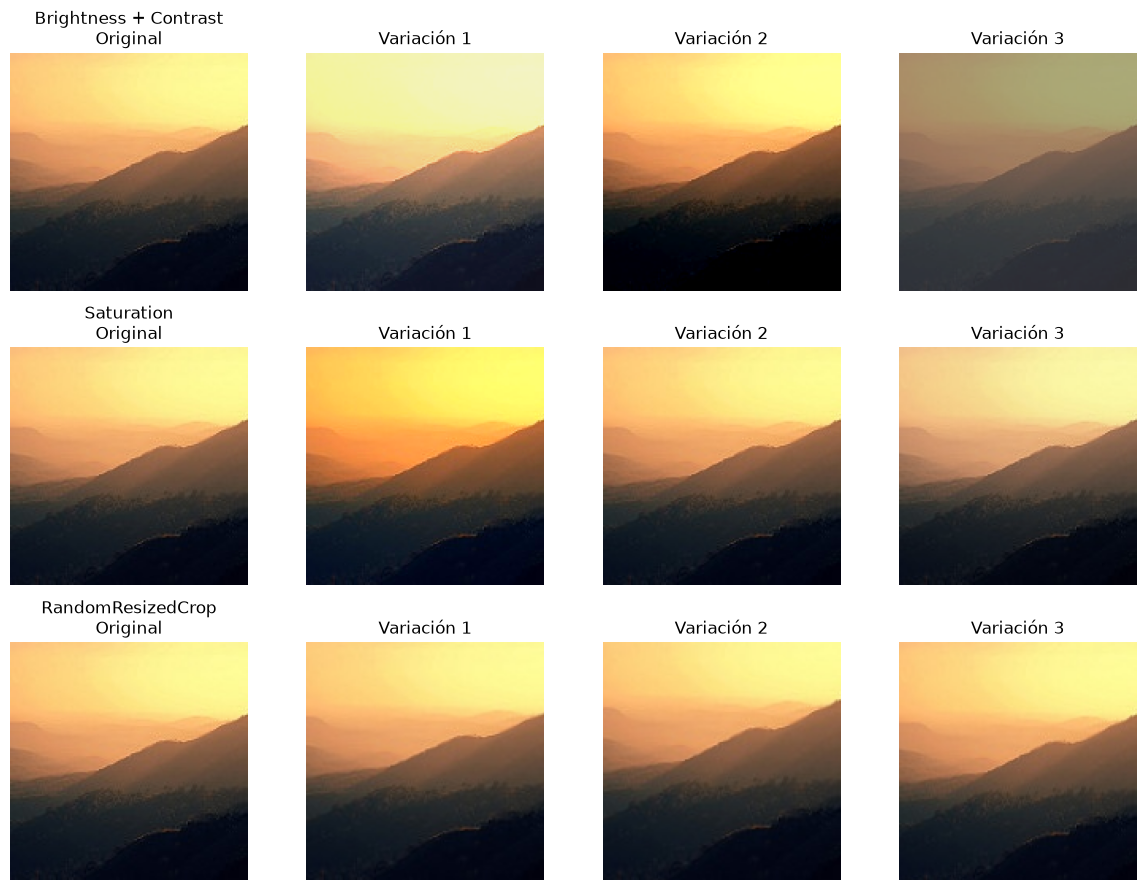

In [20]:
show_transformations(
    mountain_path,
    preview_transforms
)

## Experimento controlado

Se construyen cuatro variantes del mismo subconjunto de entrenamiento: brillo y contraste, saturación, recorte aleatorio y una combinación moderada de las tres ideas. La validación y el test usan imágenes sin aumentación aleatoria y con la misma normalización en todos los casos

In [21]:
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN,std=STD)
])

### Datasets experimentales

Todas las variantes contienen las mismas imágenes base y el mismo número de ejemplos. La diferencia es que cada acceso al subconjunto de entrenamiento puede producir una versión transformada distinta

In [22]:
brightness_full = datasets.ImageFolder(TRAIN_DIR, transform=brightness_contrast_transform)
saturation_full = datasets.ImageFolder(TRAIN_DIR, transform=saturation_transform)
crop_full = datasets.ImageFolder(TRAIN_DIR, transform=crop_transform)

In [23]:
combined_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [24]:
combined_full = datasets.ImageFolder(TRAIN_DIR, transform=combined_transform)
validation_full = datasets.ImageFolder(TRAIN_DIR, transform=evaluation_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=evaluation_transform)

In [25]:
brightness_train = Subset(brightness_full, train_indices)
saturation_train = Subset(saturation_full, train_indices)
crop_train = Subset(crop_full, train_indices)
combined_train = Subset(combined_full, train_indices)
val_dataset = Subset(validation_full, val_indices)

In [26]:
print("Brightness train:", len(brightness_train))
print("Saturation train:", len(saturation_train))
print("Crop train:", len(crop_train))
print("Combined train:", len(combined_train))

print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Brightness train: 11227
Saturation train: 11227
Crop train: 11227
Combined train: 11227
Validation: 2807
Test: 3000


## Protocolo de comparación

Los modelos se entrenan desde cero con la misma arquitectura, semilla, número máximo de épocas, batch size, optimizador y tasa de aprendizaje. Se conserva el estado con menor pérdida de validación y se evalúa una sola vez sobre el test independiente

La comparación se hará en tres niveles: dinámica de aprendizaje, accuracy global y calidad por clase

In [27]:
experiment_config = {
    "architecture": "SceneCNN",
    "parameters": 241606,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "loss": "CrossEntropyLoss",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "seed": SEED,
    "selection": "Minimum validation loss"
}

pd.DataFrame(
    experiment_config.items(),
    columns=["Elemento", "Valor"]
)

,Elemento,Valor
0,architecture,SceneCNN
1,parameters,241606
2,optimizer,Adam
3,learning_rate,0.001
4,loss,CrossEntropyLoss
5,batch_size,128
6,epochs,20
7,seed,99
8,selection,Minimum validation loss


In [28]:
experiments = {
    "Brightness + Contrast": brightness_train,
    "Saturation": saturation_train,
    "RandomResizedCrop": crop_train,
    "Combined": combined_train
}

for name, dataset in experiments.items():
    print(
        f"{name:22s} -> {len(dataset)} imágenes"
    )

Brightness + Contrast  -> 11227 imágenes
Saturation             -> 11227 imágenes
RandomResizedCrop      -> 11227 imágenes
Combined               -> 11227 imágenes


## Entrenar cada escenario bajo el mismo protocolo

La función `run_experiment` encapsula el ciclo completo: crea los `DataLoader`, inicializa una CNN nueva, entrena durante las mismas épocas, registra pérdidas y accuracy y restaura el mejor estado según la pérdida de validación

In [ ]:
def run_experiment(
    name,
    train_dataset,
    val_dataset
):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=4
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    model = SceneCNN(num_classes=len(class_names)).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    # Verificación del dispositivo
    print(f"\nExperimento: {name}")
    print("Device configurado:", device)
    print(
        "Modelo en:",
        next(model.parameters()).device
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "epoch_time": []
    }

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    for epoch in range(EPOCHS):

        start_time = time.perf_counter()

        (train_loss, train_acc, data_time, compute_time) = train_one_epoch(model, train_loader, criterion, optimizer, device)

        val_start = time.perf_counter()

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        val_time = (time.perf_counter() - val_start)
        epoch_time = (time.perf_counter() - start_time)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1

            best_model_state = copy.deepcopy(model.state_dict())

        print(
            f"{name:22s} | "
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"Train Loss {train_loss:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {val_acc:.4f} | "
            f"Data {data_time:.1f}s | "
            f"GPU {compute_time:.1f}s | "
            f"Val {val_time:.1f}s | "
            f"Total {epoch_time:.1f}s"
        )

    model.load_state_dict(best_model_state)

    return {
        "name": name,
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    }

In [30]:
brightness_experiment = run_experiment(
    "Brightness + Contrast",
    brightness_train,
    val_dataset
)


Experimento: Brightness + Contrast
Device configurado: mps
Modelo en: mps:0
Brightness + Contrast  | Epoch 01/20 | Train Loss 1.2229 | Val Loss 1.0256 | Train Acc 0.5154 | Val Acc 0.6120 | Data 6.6s | GPU 0.8s | Val 2.5s | Total 41.9s
Brightness + Contrast  | Epoch 02/20 | Train Loss 0.9445 | Val Loss 0.8336 | Train Acc 0.6409 | Val Acc 0.6804 | Data 7.0s | GPU 0.5s | Val 2.5s | Total 43.0s
Brightness + Contrast  | Epoch 03/20 | Train Loss 0.8033 | Val Loss 0.6881 | Train Acc 0.7070 | Val Acc 0.7414 | Data 7.0s | GPU 0.5s | Val 2.6s | Total 42.3s
Brightness + Contrast  | Epoch 04/20 | Train Loss 0.7049 | Val Loss 0.6379 | Train Acc 0.7487 | Val Acc 0.7720 | Data 6.6s | GPU 0.4s | Val 2.0s | Total 41.2s
Brightness + Contrast  | Epoch 05/20 | Train Loss 0.6635 | Val Loss 0.5673 | Train Acc 0.7570 | Val Acc 0.7944 | Data 4.1s | GPU 0.4s | Val 2.0s | Total 38.0s
Brightness + Contrast  | Epoch 06/20 | Train Loss 0.6067 | Val Loss 0.5641 | Train Acc 0.7810 | Val Acc 0.7923 | Data 4.1s | GPU

In [31]:
saturation_experiment = run_experiment(
    "Saturation",
    saturation_train,
    val_dataset
)


Experimento: Saturation
Device configurado: mps
Modelo en: mps:0
Saturation             | Epoch 01/20 | Train Loss 1.1473 | Val Loss 0.9778 | Train Acc 0.5463 | Val Acc 0.6402 | Data 4.2s | GPU 0.4s | Val 2.4s | Total 38.8s
Saturation             | Epoch 02/20 | Train Loss 0.8573 | Val Loss 0.7933 | Train Acc 0.6741 | Val Acc 0.6897 | Data 4.2s | GPU 0.4s | Val 2.5s | Total 38.9s
Saturation             | Epoch 03/20 | Train Loss 0.7319 | Val Loss 0.6958 | Train Acc 0.7302 | Val Acc 0.7250 | Data 4.3s | GPU 0.4s | Val 2.4s | Total 38.9s
Saturation             | Epoch 04/20 | Train Loss 0.6470 | Val Loss 0.6313 | Train Acc 0.7632 | Val Acc 0.7731 | Data 4.2s | GPU 0.4s | Val 2.5s | Total 38.9s
Saturation             | Epoch 05/20 | Train Loss 0.6069 | Val Loss 0.5663 | Train Acc 0.7790 | Val Acc 0.7923 | Data 4.1s | GPU 0.4s | Val 2.4s | Total 38.8s
Saturation             | Epoch 06/20 | Train Loss 0.5397 | Val Loss 0.5396 | Train Acc 0.8071 | Val Acc 0.8001 | Data 4.4s | GPU 0.4s | Val

In [32]:
crop_experiment = run_experiment(
    "RandomResizedCrop",
    crop_train,
    val_dataset
)


Experimento: RandomResizedCrop
Device configurado: mps
Modelo en: mps:0
RandomResizedCrop      | Epoch 01/20 | Train Loss 1.1635 | Val Loss 1.1203 | Train Acc 0.5399 | Val Acc 0.5971 | Data 3.9s | GPU 0.4s | Val 2.4s | Total 38.2s
RandomResizedCrop      | Epoch 02/20 | Train Loss 0.9025 | Val Loss 0.8299 | Train Acc 0.6532 | Val Acc 0.6829 | Data 4.1s | GPU 0.4s | Val 2.4s | Total 38.3s
RandomResizedCrop      | Epoch 03/20 | Train Loss 0.7728 | Val Loss 0.7591 | Train Acc 0.7137 | Val Acc 0.7100 | Data 4.2s | GPU 0.4s | Val 2.4s | Total 38.5s
RandomResizedCrop      | Epoch 04/20 | Train Loss 0.6948 | Val Loss 0.6556 | Train Acc 0.7479 | Val Acc 0.7620 | Data 4.3s | GPU 0.4s | Val 2.4s | Total 38.7s
RandomResizedCrop      | Epoch 05/20 | Train Loss 0.6373 | Val Loss 0.6357 | Train Acc 0.7660 | Val Acc 0.7674 | Data 4.3s | GPU 0.4s | Val 2.4s | Total 38.7s
RandomResizedCrop      | Epoch 06/20 | Train Loss 0.5817 | Val Loss 0.6012 | Train Acc 0.7892 | Val Acc 0.7777 | Data 4.1s | GPU 0.4

In [33]:
combined_experiment = run_experiment(
    "Combined",
    combined_train,
    val_dataset
)


Experimento: Combined
Device configurado: mps
Modelo en: mps:0
Combined               | Epoch 01/20 | Train Loss 1.1871 | Val Loss 1.1217 | Train Acc 0.5338 | Val Acc 0.5971 | Data 4.3s | GPU 0.4s | Val 2.5s | Total 38.7s
Combined               | Epoch 02/20 | Train Loss 0.9227 | Val Loss 0.8405 | Train Acc 0.6461 | Val Acc 0.6758 | Data 4.3s | GPU 0.3s | Val 2.0s | Total 38.3s
Combined               | Epoch 03/20 | Train Loss 0.7949 | Val Loss 0.7620 | Train Acc 0.7072 | Val Acc 0.7125 | Data 4.1s | GPU 0.4s | Val 2.5s | Total 38.5s
Combined               | Epoch 04/20 | Train Loss 0.7137 | Val Loss 0.6433 | Train Acc 0.7404 | Val Acc 0.7634 | Data 4.2s | GPU 0.4s | Val 2.5s | Total 38.6s
Combined               | Epoch 05/20 | Train Loss 0.6543 | Val Loss 0.6627 | Train Acc 0.7601 | Val Acc 0.7663 | Data 4.0s | GPU 0.4s | Val 2.5s | Total 38.4s
Combined               | Epoch 06/20 | Train Loss 0.5946 | Val Loss 0.5572 | Train Acc 0.7856 | Val Acc 0.7952 | Data 4.2s | GPU 0.4s | Val 2

In [34]:
trained_experiments = [
    brightness_experiment,
    saturation_experiment,
    crop_experiment,
    combined_experiment
]

## Comparar el comportamiento de aprendizaje y generalización

La tabla resume la época seleccionada, la pérdida de validación y la brecha final entre accuracy de entrenamiento y validación. Una brecha menor sugiere menos sobreajuste, aunque la métrica decisiva seguirá siendo el rendimiento en el test independiente

In [35]:
def training_summary(experiment):

    history = experiment["history"]

    return {
        "Experiment": experiment["name"],
        "Best epoch": experiment["best_epoch"],
        "Best val loss": experiment["best_val_loss"],
        "Final train acc": history["train_accuracy"][-1],
        "Final val acc": history["val_accuracy"][-1],
        "Final gap": (history["train_accuracy"][-1] - history["val_accuracy"][-1])
    }

In [36]:
training_comparison = pd.DataFrame([
    training_summary(experiment)
    for experiment in trained_experiments
])

training_comparison.round(4)

,Experiment,Best epoch,Best val loss,Final train acc,Final val acc,Final gap
0,Brightness + Contrast,19,0.3782,0.8719,0.8379,0.0340
1,Saturation,19,0.3918,0.8961,0.8358,0.0604
2,RandomResizedCrop,18,0.4290,0.8878,0.8237,0.0641
3,Combined,19,0.4191,0.8741,0.8276,0.0465


In [37]:
baseline_train_loss = [
    1.0410, 0.7008, 0.5778, 0.5068, 0.4624,
    0.4276, 0.3939, 0.3667, 0.3511, 0.3138,
    0.2935, 0.2789, 0.2677, 0.2317, 0.2154
]

baseline_val_loss = [
    0.8834, 0.5664, 0.5547, 0.5155, 0.4514,
    0.4525, 0.4465, 0.4096, 0.4203, 0.4263,
    0.4591, 0.3841, 0.3941, 0.4213, 0.4099
]

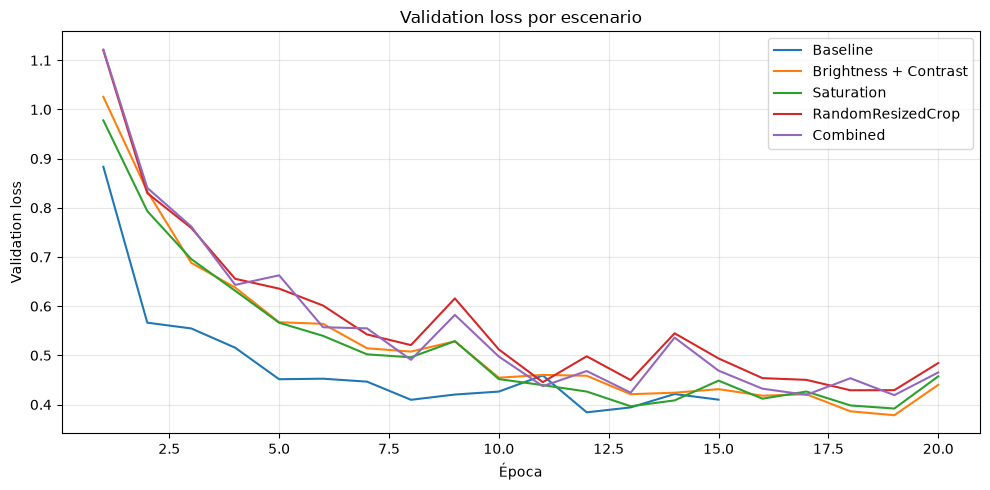

In [39]:
plt.figure(figsize=(10, 5))

# Baseline
baseline_epochs = range(1, len(baseline_val_loss) + 1)

plt.plot(baseline_epochs, baseline_val_loss, label="Baseline")

# Experimentos con aumentación
for experiment in trained_experiments:
    val_loss = experiment["history"]["val_loss"]
    experiment_epochs = range(1, len(val_loss) + 1)

    plt.plot(
        experiment_epochs, val_loss, label=experiment["name"])

plt.xlabel("Época")
plt.ylabel("Validation loss")
plt.title("Validation loss por escenario")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
baseline_val_accuracy = [
    0.6466, 0.7919, 0.7937, 0.8062, 0.8432,
    0.8351, 0.8432, 0.8561, 0.8500, 0.8568,
    0.8425, 0.8696, 0.8685, 0.8589, 0.8703
]

In [44]:
baseline_val_accuracy = [
    0.6466,
    0.7919,
    0.7937,
    0.8062,
    0.8432,
    0.8351,
    0.8432,
    0.8561,
    0.8500,
    0.8568,
    0.8425,
    0.8696,
    0.8685,
    0.8589,
    0.8703
]

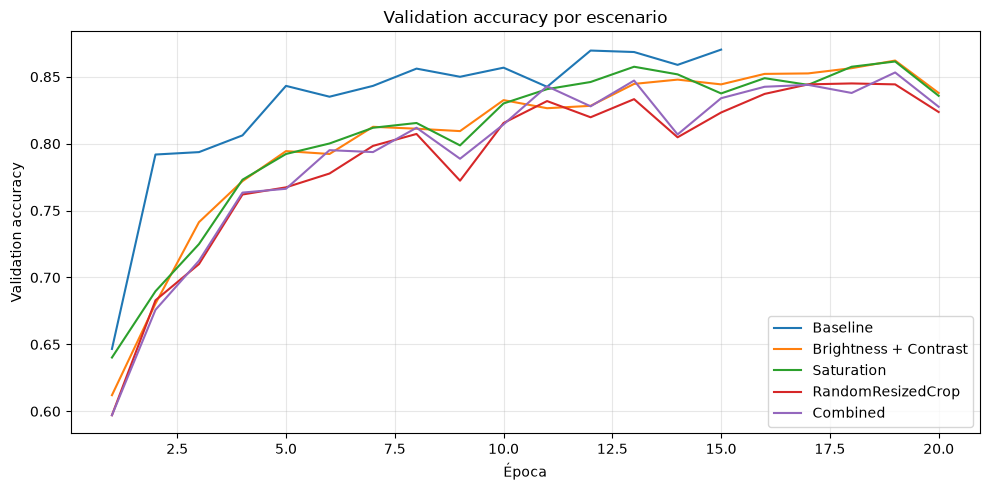

In [45]:
plt.figure(figsize=(10, 5))

# Baseline
baseline_epochs = range(
    1,
    len(baseline_val_accuracy) + 1
)

plt.plot(
    baseline_epochs,
    baseline_val_accuracy,
    label="Baseline"
)

# Experimentos con aumentación
for experiment in trained_experiments:
    val_accuracy = experiment["history"]["val_accuracy"]

    experiment_epochs = range(
        1,
        len(val_accuracy) + 1
    )

    plt.plot(
        experiment_epochs,
        val_accuracy,
        label=experiment["name"]
    )

plt.xlabel("Época")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy por escenario")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Lectura de las curvas

Las transformaciones hacen más difícil el ajuste inicial porque el modelo recibe una imagen distinta en cada pasada. En los resultados, `Brightness + Contrast` termina con la menor pérdida de validación (`0.3782`) y la brecha final más pequeña (`0.0340`); `RandomResizedCrop` presenta la mayor brecha (`0.0641`). Esto apunta a una regularización desigual: aumentar datos no garantiza por sí solo una mejor representación

## Evaluar los modelos sobre el mismo conjunto de test

El test se transforma de forma determinista y se reutiliza para todos los modelos. La accuracy permite una primera comparación global, pero no basta para saber si el modelo ha corregido el error de interés o simplemente ha desplazado errores entre clases

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

In [42]:
def evaluate_test(
    experiment,
    test_loader
):
    y_true, y_pred = predict_dataset(experiment["model"], test_loader, device)
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "name": experiment["name"],
        "accuracy": accuracy,
        "report": report,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [46]:
brightness_test = evaluate_test(brightness_experiment, test_loader)
saturation_test = evaluate_test(saturation_experiment, test_loader)
crop_test = evaluate_test(crop_experiment, test_loader)
combined_test = evaluate_test(combined_experiment, test_loader)

In [47]:
test_results = [
    brightness_test,
    saturation_test,
    crop_test,
    combined_test
]

In [48]:
accuracy_comparison = pd.DataFrame(
    [
        {
            "Experiment": "Baseline",
            "Test accuracy": 0.8620
        }
    ]
    +
    [
        {
            "Experiment": result["name"],
            "Test accuracy": result["accuracy"]
        }
        for result in test_results
    ]
)

accuracy_comparison.round(4)

,Experiment,Test accuracy
0,Baseline,0.8620
1,Brightness + Contrast,0.8660
2,Saturation,0.8547
3,RandomResizedCrop,0.8467
4,Combined,0.8470


## Comparar el desempeño por clase

El F1 combina precisión y recall, por lo que resulta especialmente informativo cuando una clase se recupera mejor a costa de aumentar falsos positivos. La tabla permite comprobar si la aumentación beneficia de forma consistente a todas las escenas o solo a una parte del problema

In [49]:
def class_metrics_table(result):

    rows = []

    for class_name in class_names:

        metrics = result["report"][class_name]

        rows.append({
            "Class": class_name,
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1-score"],
            "Support": metrics["support"]
        })

    return pd.DataFrame(rows)

In [50]:
baseline_f1 = {
    "buildings": 0.8384,
    "forest": 0.9585,
    "glacier": 0.8093,
    "mountain": 0.8197,
    "sea": 0.8795,
    "street": 0.8722
}

In [51]:
f1_rows = []

for class_name in class_names:

    row = {
        "Class": class_name,
        "Baseline": baseline_f1[class_name]
    }

    for result in test_results:
        row[result["name"]] = (
            result["report"]
            [class_name]
            ["f1-score"]
        )

    f1_rows.append(row)

f1_comparison = pd.DataFrame(f1_rows)
f1_comparison.round(4)

,Class,Baseline,Brightness + Contrast,Saturation,RandomResizedCrop,Combined
0,buildings,0.8384,0.8374,0.8409,0.8281,0.8356
1,forest,0.9585,0.9654,0.9581,0.9597,0.9432
2,glacier,0.8093,0.8247,0.8174,0.7992,0.8003
3,mountain,0.8197,0.8250,0.7996,0.7785,0.7937
4,sea,0.8795,0.8664,0.8518,0.8397,0.8533
5,street,0.8722,0.8834,0.8735,0.8767,0.8650


## `glacier` ↔ `mountain`

Este análisis descompone el error más relevante del baseline en sus dos direcciones. `G → M` mide cuántos glaciares se etiquetan como montañas; `M → G` mide el error inverso. Una transformación puede reducir la primera cifra y, al mismo tiempo, empeorar la segunda, por lo que ambas deben leerse juntas

In [52]:
glacier_idx = class_names.index("glacier")
mountain_idx = class_names.index("mountain")

In [53]:
def summarize_test_result(name, result):
    report = result["report"]
    cm = result["confusion_matrix"]

    return {
        "Experiment": name,
        "Accuracy": result["accuracy"],
        "Glacier Precision": report["glacier"]["precision"],
        "Glacier Recall": report["glacier"]["recall"],
        "Glacier F1": report["glacier"]["f1-score"],
        "Mountain F1": report["mountain"]["f1-score"],
        "G → M": int(cm[glacier_idx, mountain_idx]),
        "M → G": int(cm[mountain_idx, glacier_idx])
    }

In [54]:
comparison_rows = [
    {
        "Experiment": "Baseline",
        "Accuracy": 0.8620,
        "Glacier Precision": 0.8708,
        "Glacier Recall": 0.7559,
        "Glacier F1": 0.8093,
        "Mountain F1": 0.8197,
        "G → M": 83,
        "M → G": 45
    }
]

In [55]:
for result in test_results:
    comparison_rows.append(summarize_test_result(result["name"], result))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.round(4)

,Experiment,Accuracy,Glacier Precision,Glacier Recall,Glacier F1,Mountain F1,G → M,M → G
0,Baseline,0.8620,0.8708,0.7559,0.8093,0.8197,83,45
1,Brightness + Contrast,0.8660,0.8560,0.7957,0.8247,0.8250,66,45
2,Saturation,0.8547,0.7738,0.8662,0.8174,0.7996,50,83
3,RandomResizedCrop,0.8467,0.8390,0.7631,0.7992,0.7785,57,62
4,Combined,0.8470,0.7606,0.8445,0.8003,0.7937,51,93


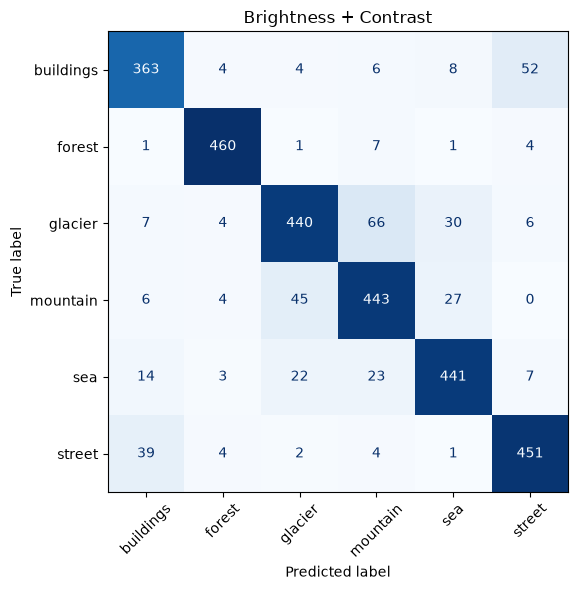

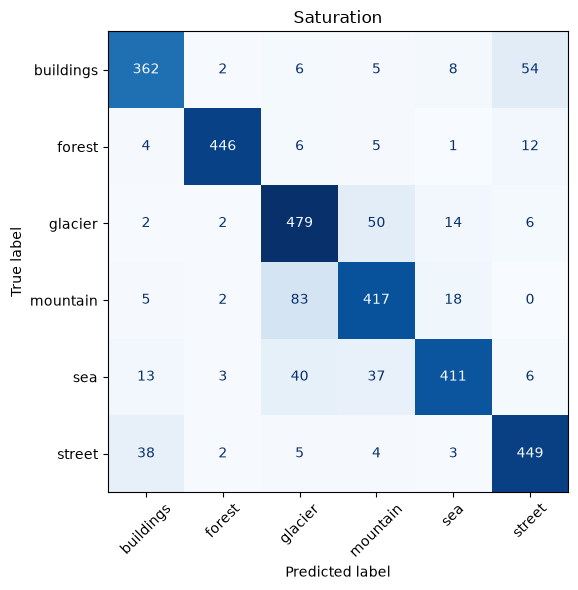

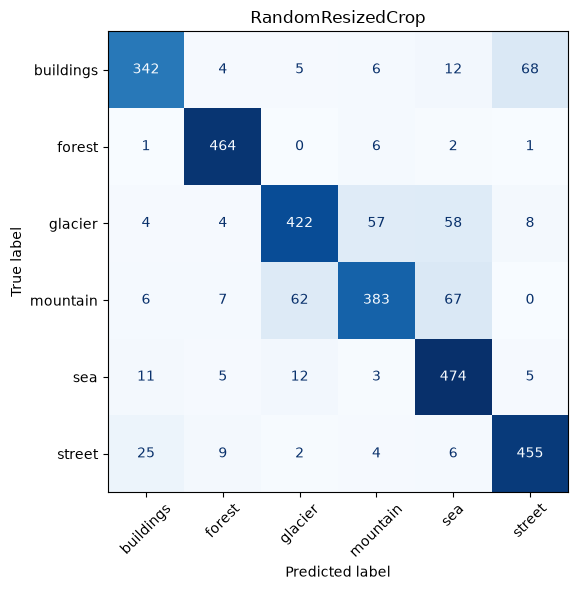

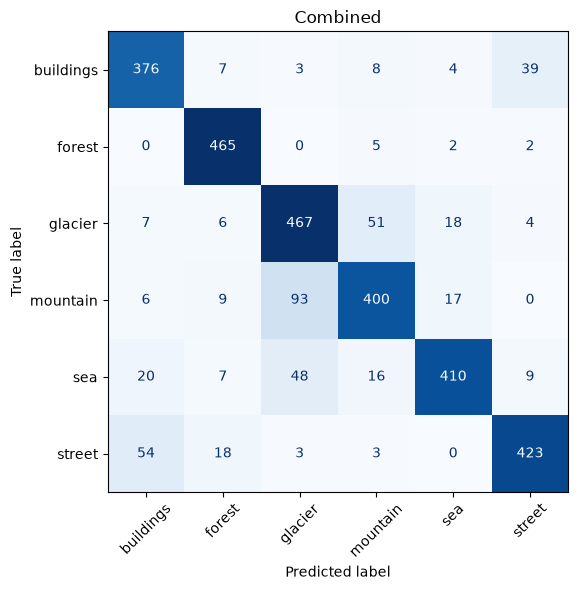

In [56]:
for result in test_results:

    fig, ax = plt.subplots(figsize=(7, 6))

    display = ConfusionMatrixDisplay(confusion_matrix= result["confusion_matrix"], display_labels=class_names)

    display.plot(ax=ax, cmap="Blues", colorbar=False)

    ax.set_title(result["name"])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Analizar visualmente qué errores cambiaron

Las métricas indican cuánto cambia el error, pero no qué tipo de imágenes lo provoca. Se inspeccionan ejemplos reales del caso `glacier → mountain` para contrastar las hipótesis: escenas dominadas por roca y relieve, nieve parcial, cielo o cambios de iluminación pueden compartir señales visuales entre ambas clases

In [57]:
visual_test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor()
    ])
)

In [58]:
y_true = combined_test["y_true"]
y_pred = combined_test["y_pred"]

g_to_m_indices = np.where((y_true == glacier_idx) & (y_pred == mountain_idx))[0]

print(
    "Glacier → Mountain:",
    len(g_to_m_indices)
)

Glacier → Mountain: 51


In [59]:
rng = np.random.default_rng(SEED)
n_examples = min(6, len(g_to_m_indices))

selected_indices = rng.choice(g_to_m_indices, size=n_examples, replace=False)

In [61]:
print("len test:", len(visual_test_dataset))
print("len y_true:", len(y_true))
print("len y_pred:", len(y_pred))

print("glacier_idx:", glacier_idx)
print("mountain_idx:", mountain_idx)

print(
    "G → M:",
    sum(
        (np.array(y_true) == glacier_idx)
        &
        (np.array(y_pred) == mountain_idx)
    )
)

len test: 3000
len y_true: 3000
len y_pred: 3000
glacier_idx: 2
mountain_idx: 3
G → M: 51


Errores glacier → mountain: 51


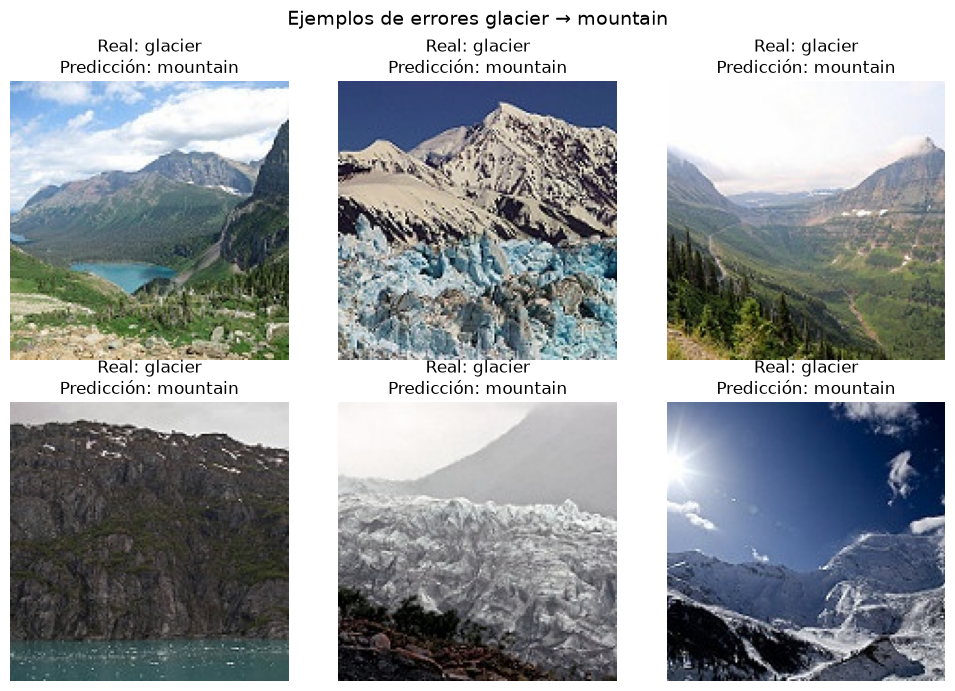

In [63]:
# Identificar errores glacier → mountain
glacier_idx = class_names.index("glacier")
mountain_idx = class_names.index("mountain")

g_to_m_indices = [
    i
    for i, (true_label, pred_label) in enumerate(
        zip(y_true, y_pred)
    )
    if true_label == glacier_idx
    and pred_label == mountain_idx
]

print(f"Errores glacier → mountain: {len(g_to_m_indices)}")

# Seleccionar 6 errores de forma reproducible
rng = np.random.default_rng(SEED)

selected_indices = rng.choice(
    g_to_m_indices,
    size=min(6, len(g_to_m_indices)),
    replace=False
)

# Visualizar
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

axes = axes.flatten()

# Apagar todos los ejes inicialmente
for ax in axes:
    ax.axis("off")

# Mostrar los errores seleccionados
for ax, idx in zip(axes, selected_indices):

    image, true_label = visual_test_dataset[idx]

    ax.imshow(image.permute(1, 2, 0).numpy())

    ax.set_title(
        f"Real: {class_names[true_label]}\n"
        f"Predicción: {class_names[y_pred[idx]]}"
    )

    ax.axis("off")

plt.suptitle(
    "Ejemplos de errores glacier → mountain",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Determinar qué aumentaciones fueron útiles, neutras o perjudiciales

Se integran en una tabla los criterios principales: pérdida de validación, brecha train-validation, accuracy de test, F1 de `glacier` y `mountain`, y las dos direcciones de confusión. La decisión final no se basa en una única métrica

In [64]:
final_rows = []

for experiment, result in zip(
    trained_experiments,
    test_results
):

    history = experiment["history"]
    report = result["report"]
    cm = result["confusion_matrix"]

    final_rows.append({
        "Experiment":experiment["name"],
        "Best epoch": experiment["best_epoch"],
        "Best val loss": experiment["best_val_loss"],
        "Final gap": (history["train_accuracy"][-1] - history["val_accuracy"][-1]),
        "Test accuracy": result["accuracy"],
        "Glacier recall": report["glacier"]["recall"],
        "Glacier F1": report["glacier"]["f1-score"],
        "Mountain F1": report["mountain"]["f1-score"],
        "G → M": int(cm[glacier_idx, mountain_idx]),
        "M → G": int(cm[mountain_idx, glacier_idx])
    })

final_comparison = pd.DataFrame(final_rows)
final_comparison.round(4)

,Experiment,Best epoch,Best val loss,Final gap,Test accuracy,Glacier recall,Glacier F1,Mountain F1,G → M,M → G
0,Brightness + Contrast,19,0.3782,0.0340,0.8660,0.7957,0.8247,0.8250,66,45
1,Saturation,19,0.3918,0.0604,0.8547,0.8662,0.8174,0.7996,50,83
2,RandomResizedCrop,18,0.4290,0.0641,0.8467,0.7631,0.7992,0.7785,57,62
3,Combined,19,0.4191,0.0465,0.8470,0.8445,0.8003,0.7937,51,93


## Conclusiones

- **Mejor resultado global:** `Brightness + Contrast` alcanza `86.60%` de accuracy en test frente a `86.20%` del baseline. También mejora el F1 de `glacier` (`0.8247` frente a `0.8093`) y de `mountain` (`0.8250` frente a `0.8197`)

- **Mejor equilibrio de generalización:** presenta la menor pérdida de validación (`0.3782`) y la menor brecha final entre train y validation (`0.0340`)

- **Saturación:** eleva el recall de `glacier` de `75.59%` a `86.62%` y reduce `G → M` de `83` a `50`, pero aumenta `M → G` de `45` a `83` y baja la accuracy global a `85.47%`. Es útil si el coste de perder glaciares es prioritario, pero no es la mejor solución equilibrada

- **Recorte y combinación:** `RandomResizedCrop` y `Combined` reducen la accuracy global hasta `84.67%` y `84.70%`, respectivamente. La combinación no suma beneficios: aumenta `M → G` hasta `93` y reduce el F1 de ambas clases frente al baseline